# Marseille et ses transports en commun : Analyse

---
## 1. Mise en place
---

### 1.1 Import

In [1]:
# Import modules

import folium 
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import branca.colormap as cm
from scipy import stats
from IPython.display import display, HTML, IFrame
import numpy as np
import os
import re
import unicodedata

# Import données
gdf_carreaux = gpd.read_file("../data/cleaned/data_marseille_tec_cleaned.geojson")
gdf_zones = gpd.read_file("../data/cleaned/data_zones_arrets.geojson")

### 1.2 Paramètres

In [2]:
# Liste des codes géographiques pour la commune de Marseille
code_geo_marseille = [str(13200 + i) for i in range(1,17)]

# Coordonnées GPS Vieux Port
vieux_port = [43.296191, 5.371370]

### 1.3 Fonction

In [3]:
'''
Le but de cette fonction est de permettre d'afficher plusieurs lignes dans la même case d'un DataFrame (Ne fonctionne que sur Jupyter Notebook)
'''

def pretty_print(df):
    return display( HTML( df.to_html().replace("\\n","<br>") ) )

In [4]:
'''
Ces fonctions visent à alléger le fichier afin qu'il puisse être affiché sur GitHub en sauvegardant les cartes interactives dans un fichier séparé
'''

maps_dir = "../docs/maps"
base_url = "https://florian-guibelin.github.io/Marseille_transport_analysis"


os.makedirs(maps_dir, exist_ok=True)

'''
Transforme un nom en nom de fichier propre
'''
def slugify(name):

    name = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode("ascii")
    name = re.sub(r"[^\w\s-]", "", name).strip().lower()
    return re.sub(r"[\s_-]+", "_", name)

    
'''
Sauvegarde une carte Folium en HTML autonome dans docs/maps/
et retourne un IFrame léger à afficher dans le notebook,
au lieu d'embarquer les ~8 Mo de HTML de la carte complète.
'''
def save_and_embed(m, name, width=800, height=500):

    filename = f"{slugify(name)}.html"
    filepath = os.path.join(maps_dir, filename)
    m.save(filepath)

    src = f"{base_url}/maps/{filename}" if base_url else filepath
    return IFrame(src, width=width, height=height)

---
## 2. Analyse exploratoire des données
---

### 2.1 Données construites 

#### 2.1.1 Variables continues

Les variables continues sont celles qui concernent les distances entre le carreau et un nombre donné de lignes.

In [5]:
var_continues = ["dist_min_1_ligne", "dist_min_2_lignes", "dist_min_3_lignes", "dist_min_4_lignes", "dist_min_5_lignes", 
                 "dist_min_6_lignes","dist_vieux_port"]

##### a) Statistiques descriptives

In [6]:
gdf_carreaux[var_continues].describe().round(2)

,dist_min_1_ligne,dist_min_2_lignes,dist_min_3_lignes,dist_min_4_lignes,dist_min_5_lignes,dist_min_6_lignes,dist_vieux_port
count,3243.00,3243.00,3243.00,3243.00,3243.00,3243.00,3243.00
mean,129.89,206.27,351.76,531.08,890.28,1156.30,6100.94
std,273.87,336.28,439.09,601.77,917.05,1011.68,2746.88
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,47.34,107.68,250.78,395.56,4174.37
50%,36.68,91.84,216.73,348.57,632.40,911.17,6130.60
75%,149.80,269.61,492.68,739.31,1230.67,1675.98,7978.06
max,4064.65,4064.65,4236.48,4595.85,6455.33,6455.33,13077.74


Observations :
---
- On voit les moyennes et les écarts-types augmenter, ce qui est logique étant donné que la contrainte sur le nombre de lignes est de plus en plus importante. C'est également valable pour la distance au Vieux Port puisqu'il s'agit d'un point fixe.
- Cette augmentation est aussi visible pour les différent quartiles, même si concernant le passage d'une à deux lignes, Q1 et le maximum sont égaux.
- Le minimum est toujours égal à 0 car il y a toujours au moins un carreau qui contient une zone répondant au critère posé.
- Les moyennes sont quasi-systématiquement supérieures aux médianes, excepté pour la distance au Vieux Port. Cela suggère la présence de valeurs extrèmes sur le haut de la distribution. Cet écart diminue au fur et à mesure de l'augmentation du nombre de lignes, ce qui suggère un écrasement de celle-ci.
- Les écarts assez faibles entre le minimum, Q1, la médiane et Q3 indiquent une concentration des données sur le bas des distributions.

##### b) Visualisation

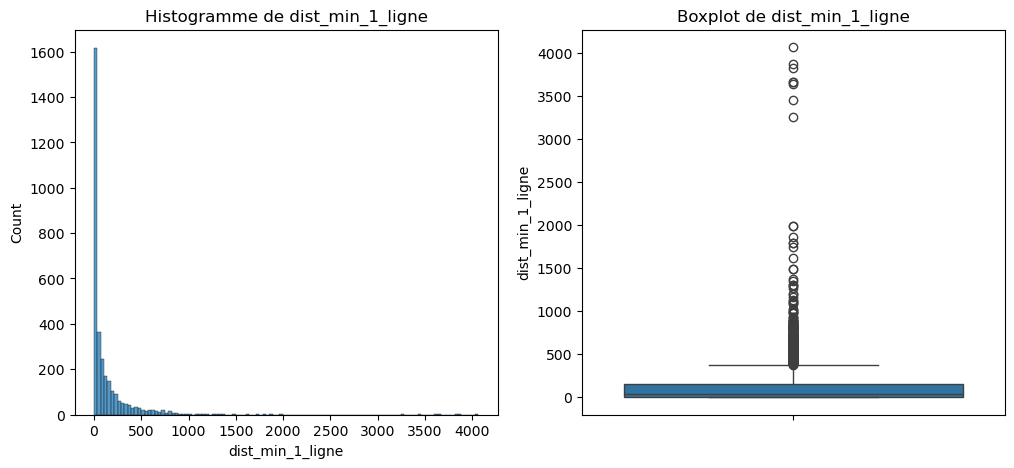

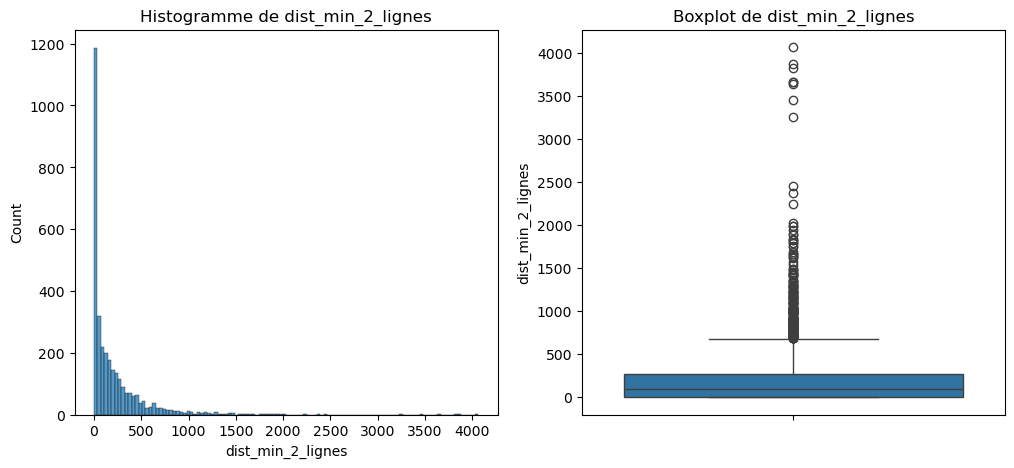

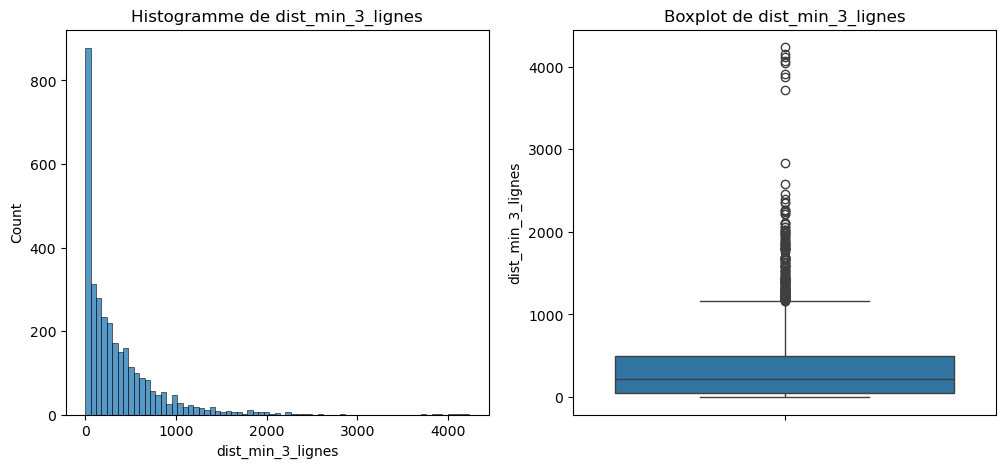

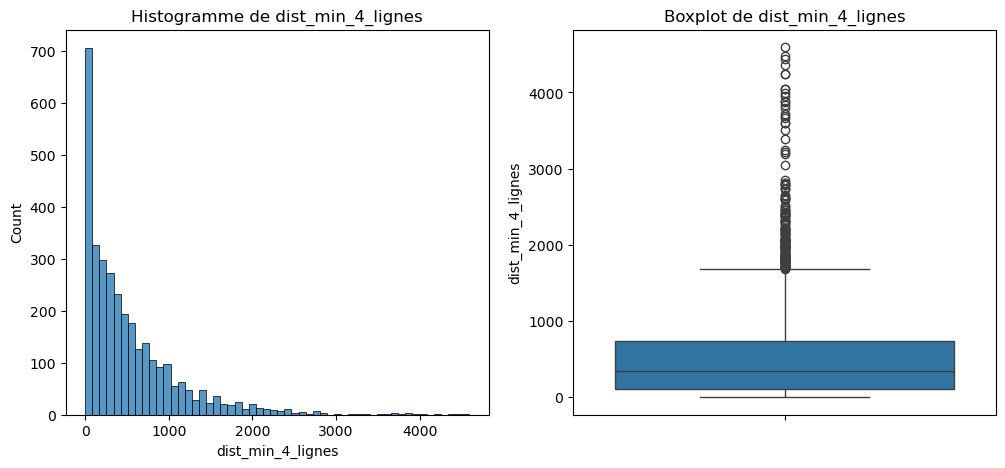

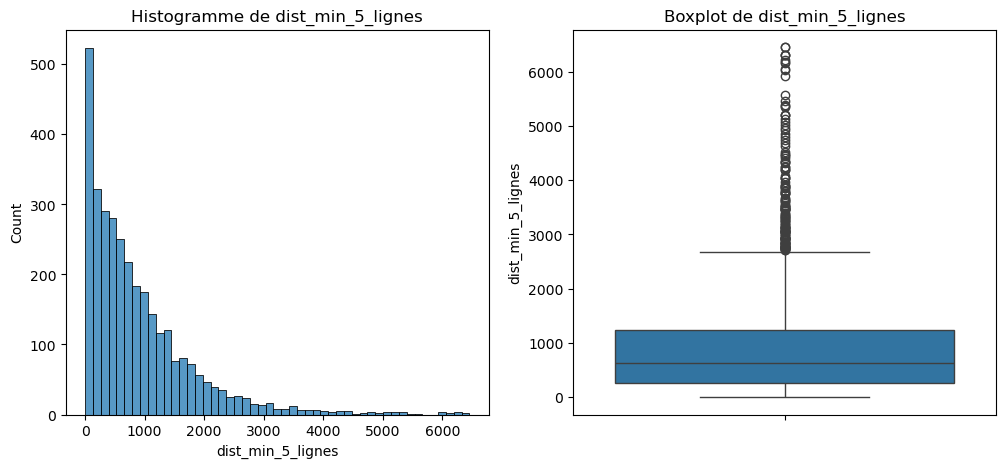

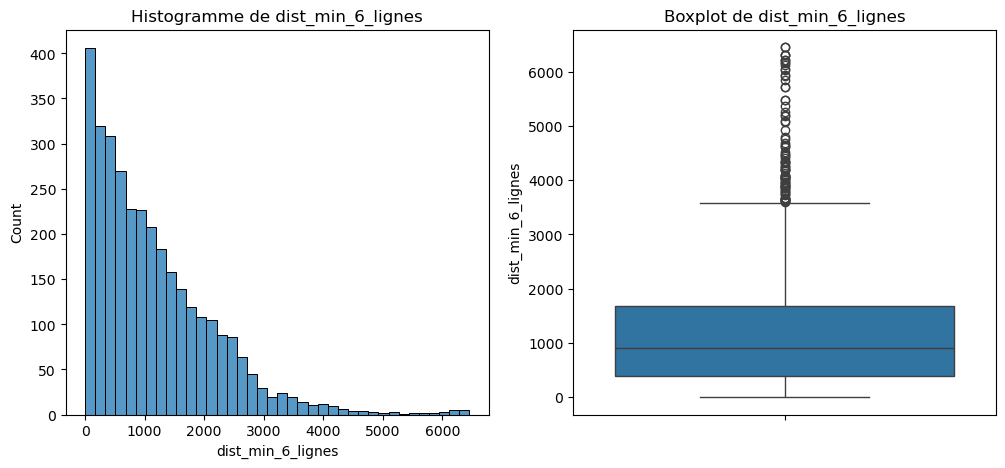

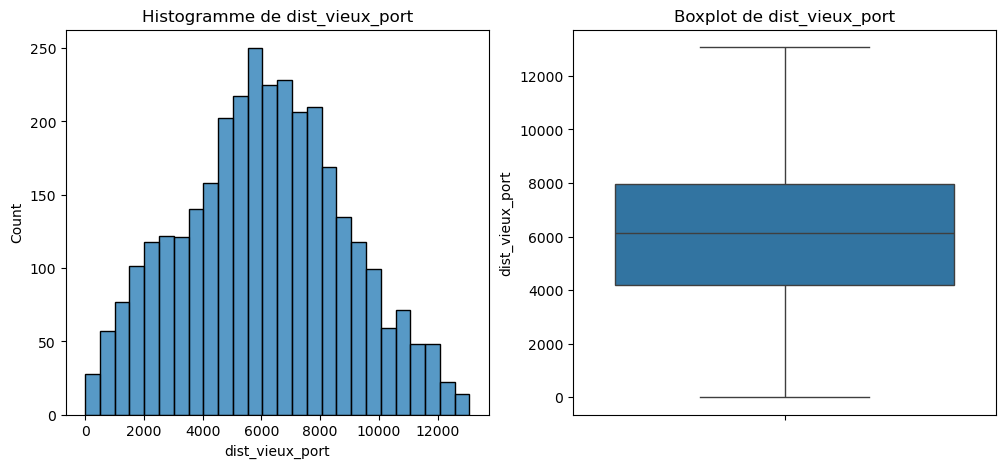

In [7]:
# Pour chaque variable dans la liste des variables continues
for var in var_continues :
    plt.figure(figsize = (12,5))
    plt.subplot(1,2,1)

    # On fait un histogramme
    sns.histplot(gdf_carreaux[var])
    plt.title(f"Histogramme de {var}")

    plt.subplot(1,2,2)

    # On fait une boîte à moustache
    sns.boxplot(gdf_carreaux[var])
    plt.title(f"Boxplot de {var}")
    
    plt.show()

Interprétations :
---
- Comme envisagé plus tôt, les distributions, à l'exception de la distance au Vieux Port, sont particulièrement concentrées sur le bas et s'écrasent avec l'augmentation du nombre de lignes requis.
- Les boxplot détectent de nombreuses valeurs aberrantes. Il s'agit sans doute d'un effet statistique dû à la très forte concentration des données. On peut vérifier cela en observant où se situent les carreaux incriminés sur la carte ci-dessous. Ceci témoigne principalement de la grande étendue géographique de la ville de Marseille.
- La distance au Vieux Port correspond à une distribution normale, qui semble légèrement biaisée vers la gauche. Aucune valeur aberrante n'est détectée. 

In [8]:
# Carte avec plusieurs couches présentant les carreaux détectés comme valeur aberrantes, ainsi que les zones d'arrêts
m = folium.Map(vieux_port, zoom_start=12, tiles="cartodbpositron")

# Pour toutes les pairs entre nombre de lignes et distance à partir de laquelle une valeur est jugée aberrante
for i,j in zip(range(1,7), (500, 500, 1000, 1500, 2500, 3500)) :

    # On ajoute un "s" à ligne s'il y a plus d'une ligne
    if i == 1 :
        k = ""
    else :
        k = "s" 
    
    # On crée une couche avec les carreaux concernés
    folium.GeoJson(gdf_carreaux[gdf_carreaux[f"dist_min_{i}_ligne{k}"] > j],
                  popup = folium.GeoJsonPopup(fields=[f"dist_min_{i}_ligne{k}"]),
                   name = f"> {j}m {i} ligne{k}",
                   # On ne montre au début que la couche pour dist_min_1_ligne
                   show = (i == 1),
                  style_function = lambda x: {'fillColor': "black", "color" : "black"}).add_to(m) 

# On ajoute les zones d'arrêts
folium.GeoJson(gdf_zones[["geometry", "nom_zone", "nombre_ligne"]], 
              popup = folium.GeoJsonPopup(fields=["nom_zone", "nombre_ligne"]),
              name = "zones").add_to(m)

folium.LayerControl().add_to(m)

save_and_embed(m, "carreaux_aberrants_lignes")

#### 2.1.2 Variables discrètes

Les variables discrètes sont celles sur le nombre de zones et de lignes dans un certain périmètre.

In [9]:
var_discretes = ["zones_inside", "zones_100m", "zones_200m", "nombre_lignes_inside", "nombre_lignes_100m", "nombre_lignes_200m"]

##### a) Statistiques descriptives

In [10]:
gdf_carreaux[var_discretes].describe().round(2)

,zones_inside,zones_100m,zones_200m,nombre_lignes_inside,nombre_lignes_100m,nombre_lignes_200m
count,3243.00,3243.00,3243.00,3243.00,3243.00,3243.00
mean,0.45,1.49,3.04,1.12,2.44,3.64
std,0.67,1.48,2.52,2.09,2.90,3.66
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,1.00,0.00,0.00,1.00
50%,0.00,1.00,3.00,0.00,2.00,3.00
75%,1.00,2.00,4.00,2.00,4.00,5.00
max,4.00,9.00,14.00,17.00,21.00,29.00


Observations : 
---
- A mesure que la contrainte se fait plus lâche, une hausse du périmètre considéré, moyennes et écarts-types augmentent. Ceci est logique puisque plus la surface est grande, plus le nombre de zones, donc de lignes, qui y sont incluses augmente. La hausse de l'écart-type indique que cela entraine une dispersion plus importante des données.
- Il en va de même pour les différents quartiles qui augmentent presque systématiquement.
- Les minimums sont toujours nuls puiqu'il y a toujours au moins un carreau répondant au critère posé.
- Les moyennes sont supérieures aux médianes, indiquant la présence de valeurs extrèmes sur le haut de la distribution.
- Les quartiles indiquent une concentration sur le bas de la distribution. 

##### b) Visualisation

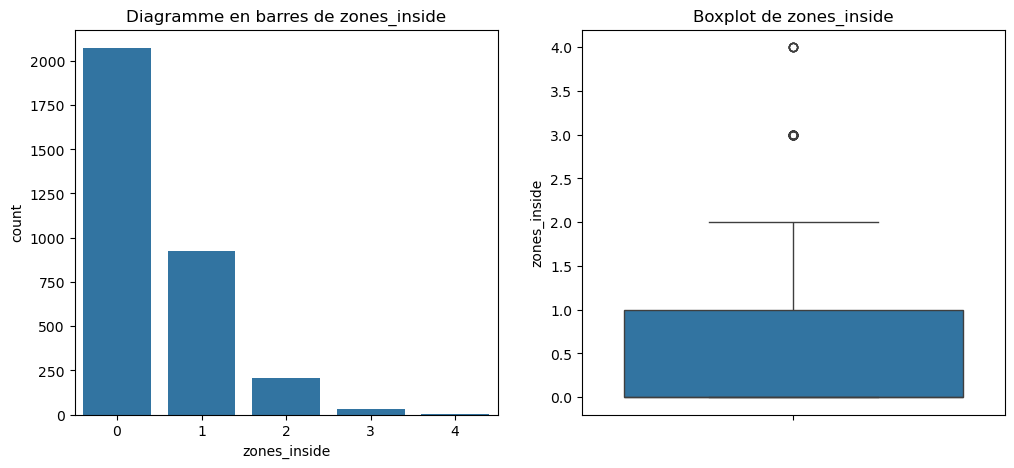

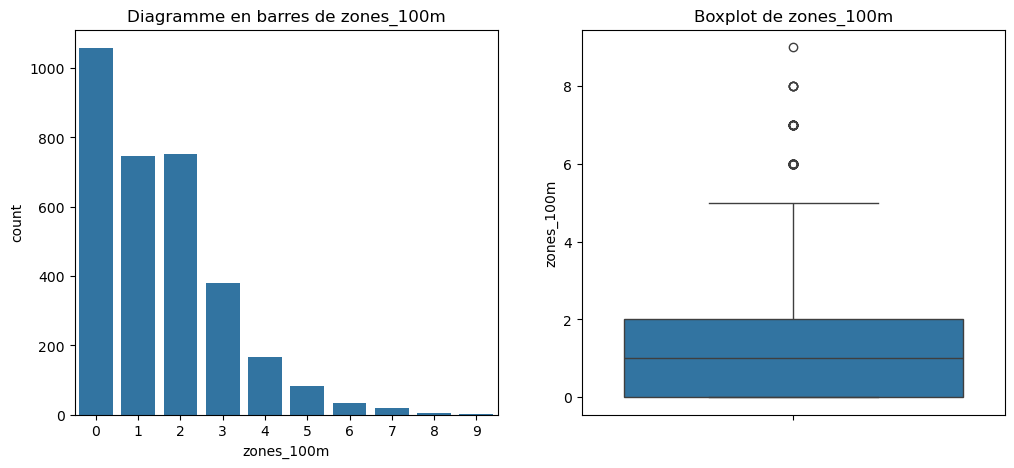

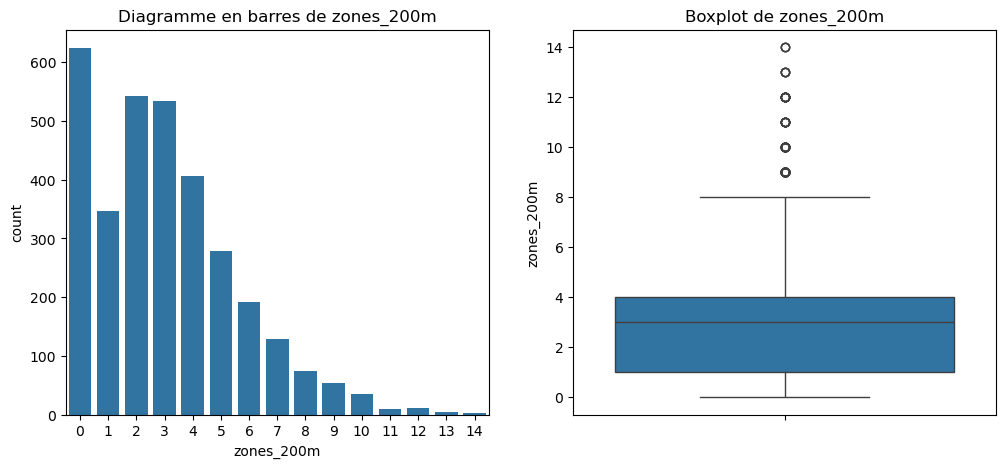

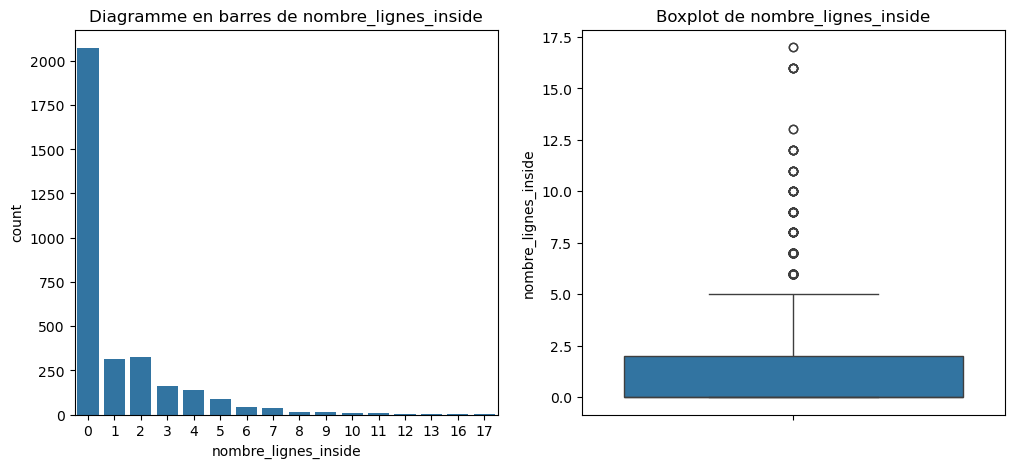

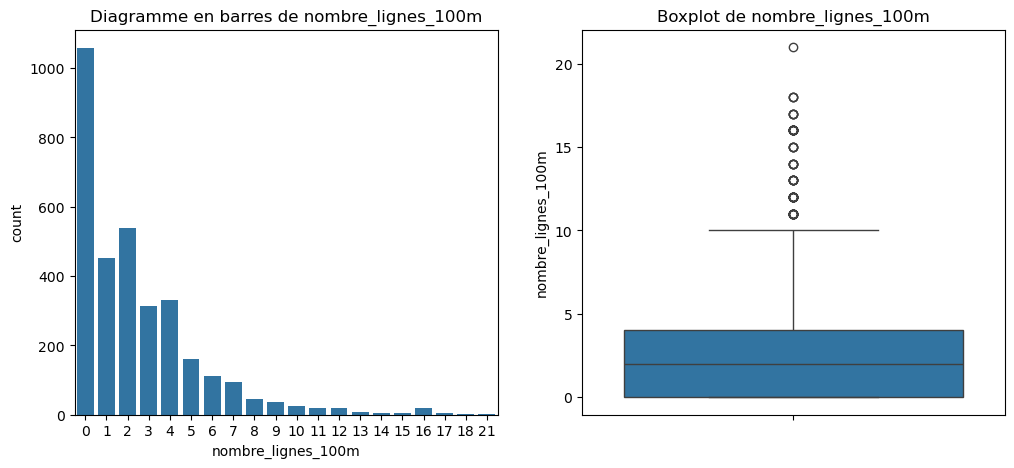

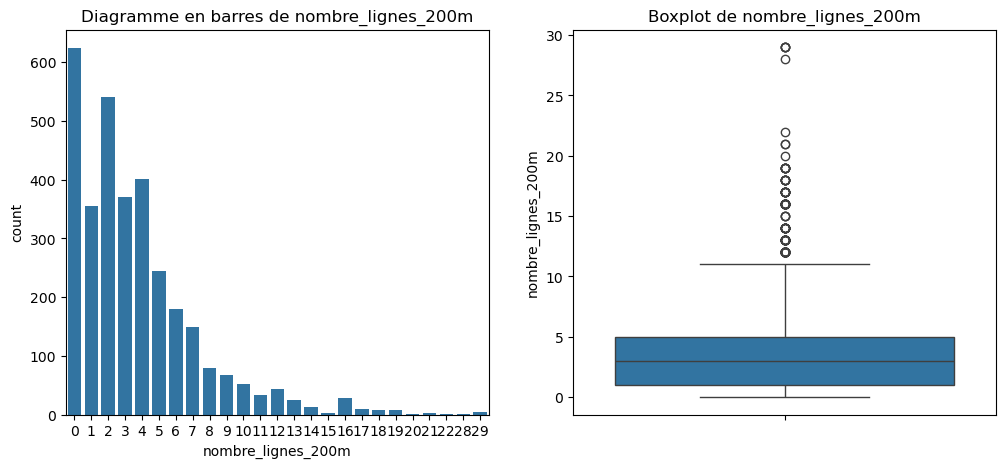

In [11]:
# Pour chaque variable dans la liste des variables discrètes
for var in var_discretes :
    plt.figure(figsize = (12,5))
    plt.subplot(1,2,1)

    # On fait un diagramme en barre
    sns.countplot(x = f"{var}", data = gdf_carreaux)
    plt.title(f"Diagramme en barres de {var}")

    plt.subplot(1,2,2)

    # On fait une boîte à moustache
    sns.boxplot(gdf_carreaux[var])
    plt.title(f"Boxplot de {var}")
    
    plt.show()

Interprétations : 
---
- Comme précédemment les distributions sont fortement concentrées sur le bas, mais s'écrasent au fur et à mesure que le périmètre considéré augmente.
- La proportion de carreaux à 1 zones diminuent avec l'augmentation du périmètre. Cela suggère une concentration géographique des zones : si on est déjà à proximité d'une zone d'arrêts, il y a une forte probabilité qu'une seconde soit proche également.
- Les valeurs détectées comme aberrantes sont certainement encore une fois le fruit de la grande concentration des données. On peut vérifier dans la carte ci-dessous, en orange les carreaux "aberrants" selon le nombre de zones et en bleu ceux selon le nombre de lignes.

In [12]:
# Carte avec plusieurs couches présentant les carreaux détectés comme valeur aberrantes, ainsi que les zones d'arrêts

m = folium.Map(vieux_port, zoom_start=12, tiles="cartodbpositron")

# Pour chaque pair entre le périmètre considéré et le nombre de zones à l'intérieur détecté comme aberrant
for i,j in zip(("inside", "100m", "200m"), (2, 5, 8)) :
    
    # On fait une couche des carreaux détectés comme aberrant    
    folium.GeoJson(gdf_carreaux[gdf_carreaux[f"zones_{i}"] > j],
                  popup = folium.GeoJsonPopup(fields=[f"zones_{i}"]),
                   name = f"> {j} zones {i}",
                   # On ne montre en premier que la facette "inside"
                   show = (i == "inside"),
                  style_function=lambda x: {'fillColor': 'orange', "color" : "orange"}).add_to(m) 

# Idem que précédemment pour le nombre de lignes 
for i,j in zip(("inside", "100m", "200m"), (5, 10, 11)) : 
            
    folium.GeoJson(gdf_carreaux[gdf_carreaux[f"nombre_lignes_{i}"] > j],
                  popup = folium.GeoJsonPopup(fields=[f"nombre_lignes_{i}"]),
                   name = f"> {j} lignes {i}",
                   show = (i == "inside"),
                  style_function=lambda x: {'fillColor': 'blue', "color" : "blue"}).add_to(m) 

# On ajoute les zones d'arrêts
folium.GeoJson(gdf_zones[["geometry", "nom_zone", "nombre_ligne"]], 
              popup = folium.GeoJsonPopup(fields=["nom_zone", "nombre_ligne"]),
              name = "zones").add_to(m)

folium.LayerControl().add_to(m)

save_and_embed(m, "carreaux_aberrants_zones")

### 2.2 Données INSEE

Etant donné le nombre important de colonnes, seules certaines seront étudiées dans cette partie. A cause de l'imputation, beaucoup de variables, logiquement discrètes, deviennent de fait continues.

In [13]:
col = ["ind", "men", "men_pauv", "log_soc", "ndv_moy_tous", "ndv_moy_adulte"]

In [14]:
# Proportion de carreaux imputés dans l'ensemble 
len(gdf_carreaux[gdf_carreaux["i_est_200"] == True])/len(gdf_carreaux)

0.2133826703669442

In [15]:
# Proportion de la population dans un carreau imputé
sum(gdf_carreaux[gdf_carreaux["i_est_200"] == True]["ind"])/sum(gdf_carreaux["ind"])

0.012684299872360862

21% des carreaux présents dans l'ensemble sont imputés, représentant 1,2% de la population.

In [16]:
gdf_carreaux[col].describe().round(2)

,ind,men,men_pauv,log_soc,ndv_moy_tous,ndv_moy_adulte
count,3243.00,3243.00,3243.00,3243.00,3243.00,3243.00
mean,240.14,112.64,26.45,20.89,26541.84,33395.89
std,314.95,151.51,50.65,68.10,6720.50,7947.54
min,1.00,0.30,0.00,0.00,11768.46,12580.24
25%,38.00,15.15,1.00,0.00,21759.54,27845.08
50%,119.50,50.00,6.00,0.00,26675.10,32767.18
75%,303.75,144.00,26.00,1.00,31095.41,38251.22
max,3523.50,1781.00,561.00,1000.00,48791.78,67913.98


Observations : 
---
- Pour les 4 premières variables, les moyennes sont bien plus élevées que les médianes, et les écarts-types plus élevés que les moyennes. Les écarts entre Q3 et le maximum sont très important, avec un rapport minimal de 1 à 10 entre les deux valeurs. Ceci suggère que les distributions sont particulièrement dispersées et concentrées sur le bas, mais avec des valeurs extrèmes très fortes.
- Cette concentration est impressionante concernant les ménages vivant dans un logement social (log_soc) puisque dans 75% des carreaux, il y a 1 ménage ou moins qui vit dans un logement social, 50% au moins avec aucun ménage dans un logement social même, et les 25% restant se répartissent entre 1 et 1000 ménages.
- Concernant les niveaux de vie moyen des carreaux, moyennes et médianes sont très proches. Les écarts-types sont relativement faibles par rapport à ces dernières, indiquant des données peu étalées.

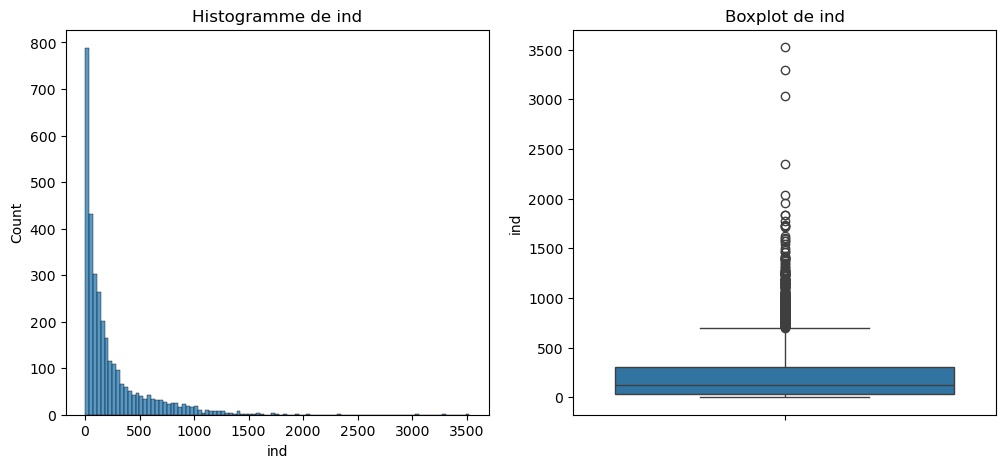

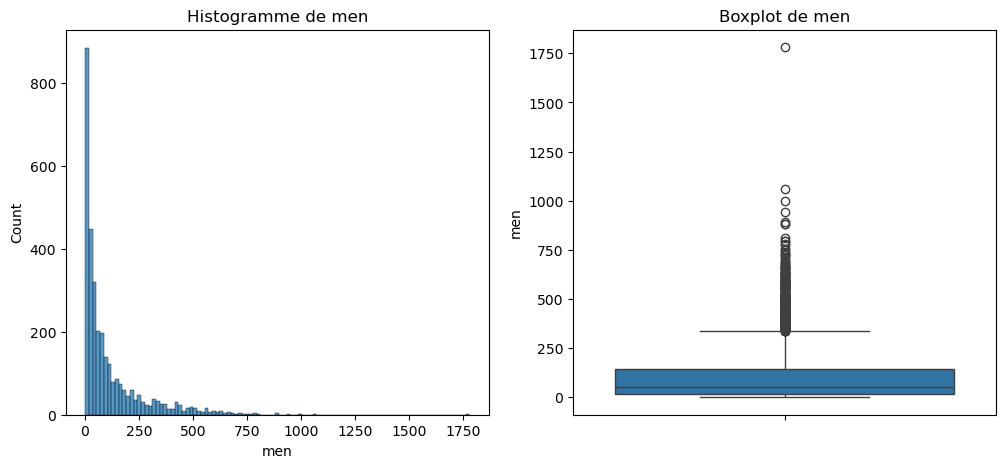

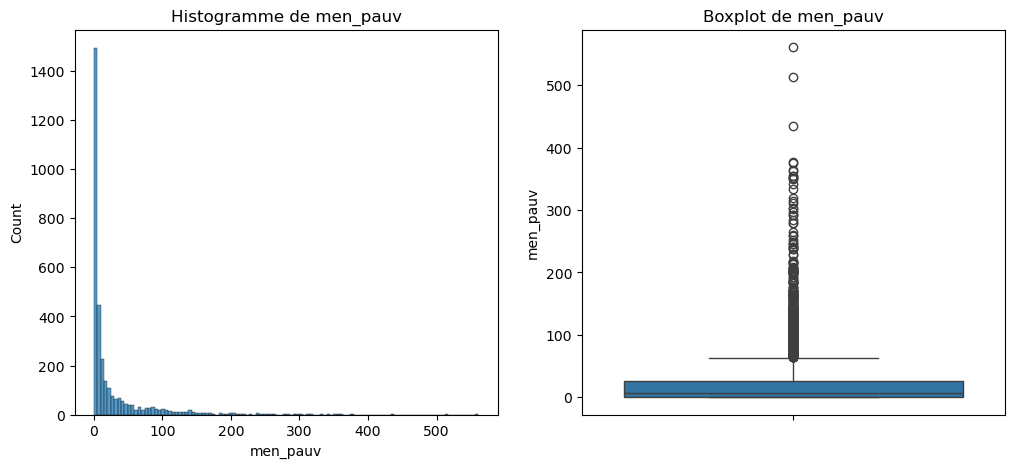

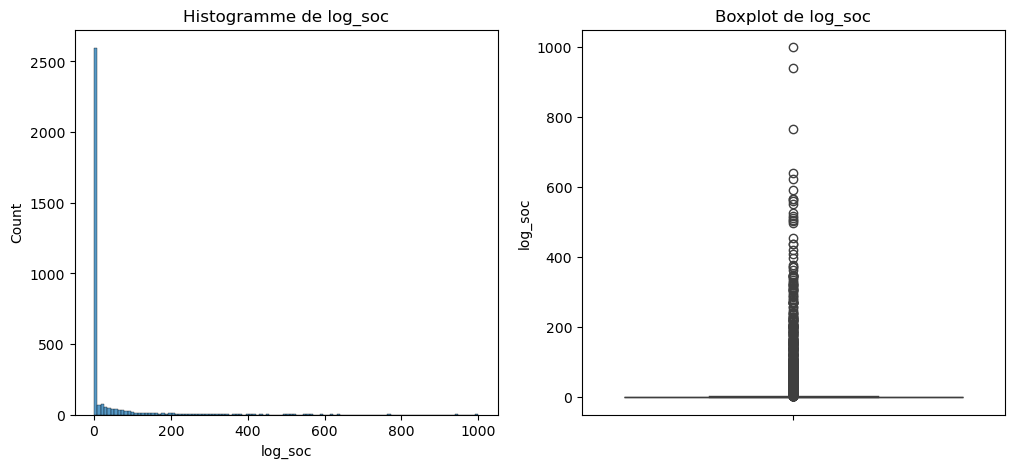

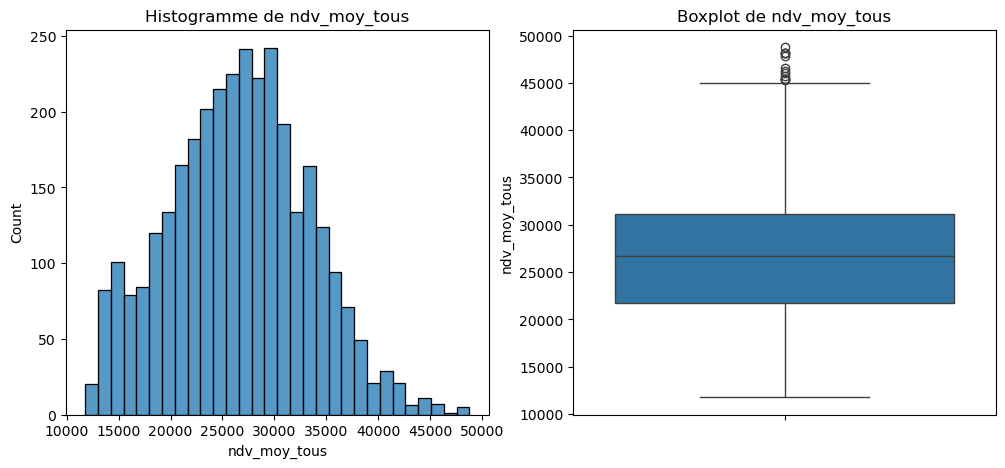

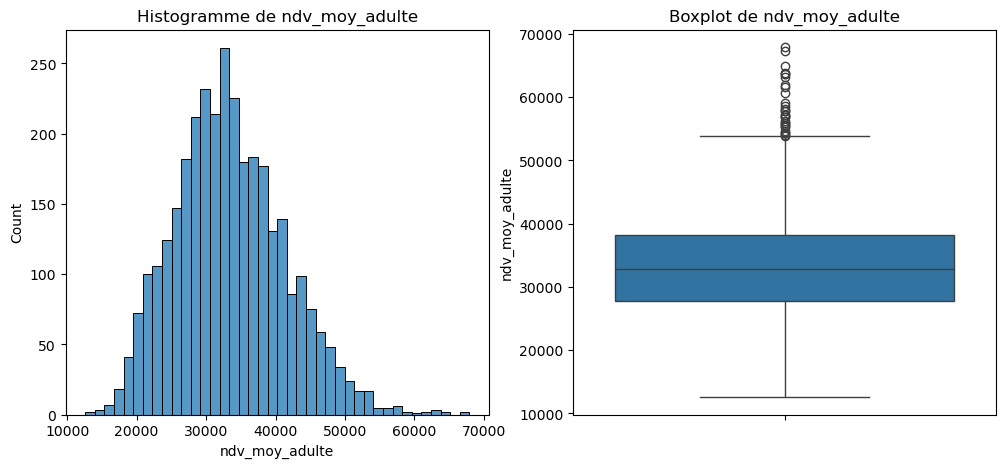

In [17]:
# Pour chaque colonne étudié
for var in col :
    plt.figure(figsize = (12,5))
    plt.subplot(1,2,1)

    # On fait un histogramme
    sns.histplot(gdf_carreaux[var])
    plt.title(f"Histogramme de {var}")

    plt.subplot(1,2,2)

    # On fait une boîte à moustache
    sns.boxplot(gdf_carreaux[var])
    plt.title(f"Boxplot de {var}")
    
    plt.show()

Interprétations : 
--- 
- De nouveau, ces données suggèrent une concentration géographique des habitants dans quelques carreaux.
- Cette concentration semble être aussi bien démographique que socio-économique comme le laissent penser les données sur les logements sociaux.
- Sur les niveaux de vie standardisés par rapport aux nombre d'habitants totaux ou majeurs dans le carreau, les distributions sont des distributions normales asymétriques à gauche. Les valeurs les plus élevées sont d'ailleurs détectées comme aberrantes. 
- Les cartes ci-dessous présentent la répartition géographique des variables.

In [18]:
# Nom des différentes cartes 
noms = ("Nombre d'individus", "Nombre de ménages", "Nombre de ménages pauvres", "Nombre de ménages en logement social", 
        "Niveau de vie moyen par habitant", "Niveau de vie moyen par adulte")

maps = {}
for i, j in zip(col, noms) :

    # Couleurs de chaque carte
    if i == col[0] :
        palette = cm.linear.OrRd_09
    elif i == col[1] :
        palette = cm.linear.Blues_09
    elif i == col[2] :
        palette = cm.linear.Greens_09
    elif i == col[3] :
        palette = cm.linear.GnBu_09	
    elif i == col[4] :
        palette = cm.linear.Purples_09
    else :
        palette = cm.linear.BuGn_09

    # Légende
    colormap = palette.scale(
        gdf_carreaux[i].min(),
        gdf_carreaux[i].max()
    )
    colormap.caption = j

    # Point de départ de la carte
    m = folium.Map(location=vieux_port, zoom_start=12, tiles="cartodbpositron")

    # Fonction permettant d'associer les couleurs aux cartes
    def style_function(feature, colname=i, cmap=colormap):
        value  = feature["properties"].get(colname)

        return {
            "fillColor": cmap(value) if value is not None else "#cccccc",
            "color": "black",
            "weight": 0.1,
            "fillOpacity": 0.7
        }

    # Création de la carte chloropèthe
    folium.GeoJson(
        gdf_carreaux,
        name = j,
        style_function = style_function,
        tooltip = folium.GeoJsonTooltip(
            fields=["idcar_200m",i],
            aliases=["ID",j],
            localize=True
        )
    ).add_to(m)

    # Ajout de la légende
    colormap.add_to(m)

    maps[j] = m

In [19]:
for name, m in maps.items():
    print(name)
    display(save_and_embed(m, name))

Nombre d'individus


Nombre de ménages


Nombre de ménages pauvres


Nombre de ménages en logement social


Niveau de vie moyen par habitant


Niveau de vie moyen par adulte


Observations : 
---
- Les cartes "Nombre d'individus" et "Nombre de ménages" sont très similaires, tout comme les cartes "Niveau de vie moyen par habitant" et "Niveau de vie moyen par adulte". On peut donc ne mobiliser qu'une seule des deux variables à chaque fois.
- On remarque que les zones les plus peuplées se trouvent plutôt dans le centre-ville, c'est-à-dire autour du Vieux Port, mais les carreaux les plus densément peuplées sont dans les arrondissements extérieurs et correspondent à des cités comme La Castellane au nord et la Rouvière au sud (respectivement CRS3035RES200mN2262600E3942600 et CRS3035RES200mN2249400E3948600).
- Les ménages les plus pauvres et les zones aux niveaux de vie les plus faibles se situent tendanciellement dans les zones les plus peuplées mais plus au nord qu'au sud. 

---
## 3. Liens entre géographie, démographie et socio-économie dans les données
---

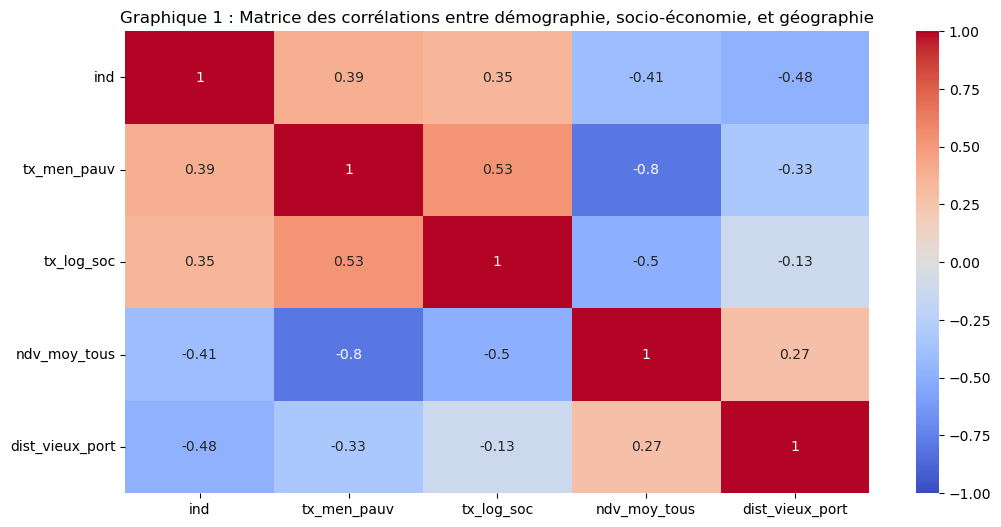

In [20]:
# Variables étudiées dans la matrice de corrélation
var_corr = ["ind", "tx_men_pauv", "tx_log_soc", "ndv_moy_tous", "dist_vieux_port"]

# Matrice de corrélation
plt.figure(figsize = (12,6))
sns.heatmap(gdf_carreaux[var_corr].corr(), annot = True, cmap = "coolwarm", vmin = -1, vmax = 1)
plt.title("Graphique 1 : Matrice des corrélations entre démographie, socio-économie, et géographie")

plt.show()

Interprétations : 
--- 
- Plus on s'approche du Vieux Port, plus le nombre d'habitants, le taux de ménage pauvre et le taux de ménage en logement social sont élevés, et plus le niveau de vie est bas.
- Les zones les plus peuplées sont plus proche du Vieux Port, avec des niveaux de vie plus faible et des taux de ménage pauvre et de ménage en logement social plus élevés. 

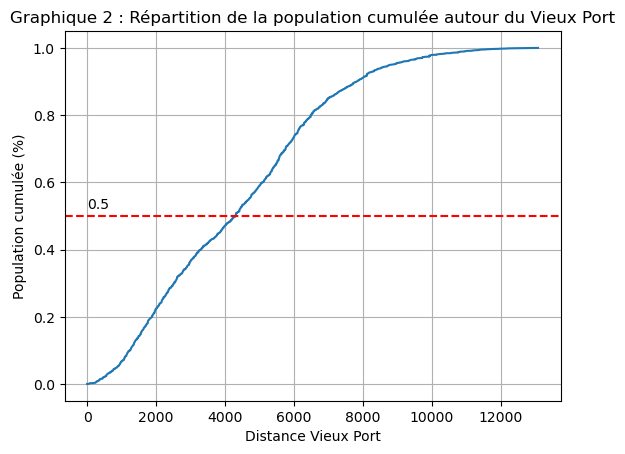

In [21]:
# Trier par distance
df = gdf_carreaux.sort_values("dist_vieux_port")

# Population cumulée
df["pop_cum"] = df["ind"].cumsum()

# Proportion de la population cumulée
df["pop_pct"] = df["pop_cum"] / df["ind"].sum()

plt.plot(df["dist_vieux_port"], df["pop_pct"])
    
plt.xlabel("Distance Vieux Port")
plt.ylabel("Population cumulée (%)")
plt.title("Graphique 2 : Répartition de la population cumulée autour du Vieux Port")
plt.grid()
plt.axhline(0.50, linestyle = "--", color = "red")
plt.text(0,0.52,"0.5")

plt.show()

Interprétations : 
---
- Comme pressenti plus haut, on voit une forte concentration de la population autour du Vieux-Port.
- On a un habitant sur 2 qui vit à environ 4km ou moins du Vieux-Port.
- A 6km ou moins, on passe à plus de 70% de la population marseillaise dans ce rayon.

---
## 4. Le réseau de transport dans la ville
---

### 4.1 Accès au réseau pour la population

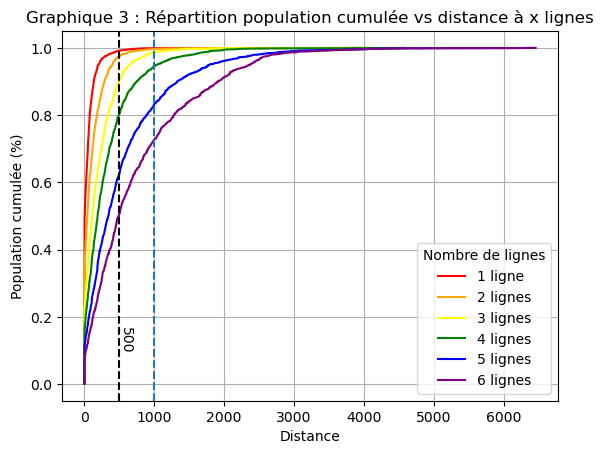

In [22]:
# Couleurs des différentes courbes
couleurs = ("red", "orange", "yellow", "green", "blue", "purple")

for i,j in zip(range(1,7), couleurs) :
    if i == 1:
        k = ""
    else :
        k = "s"

    # Trier par distance
    df = gdf_carreaux.sort_values(f"dist_min_{i}_ligne{k}")
    
    # Population cumulée
    df["pop_cum"] = df["ind"].cumsum()

    # Pourcentage de la population cumulée
    df["pop_pct"] = df["pop_cum"] / df["ind"].sum()
    
    plt.plot(df[f"dist_min_{i}_ligne{k}"], df["pop_pct"], color = j, label = f"{i} ligne{k}")
    
plt.xlabel("Distance")
plt.ylabel("Population cumulée (%)")
plt.title("Graphique 3 : Répartition population cumulée vs distance à x lignes")

# Ligne verticale à 500m
plt.axvline(500, color = "black", linestyle = "--")
plt.text(500,0.1,"500",rotation=270)

# Ligne verticale à 1km
plt.axvline(1000, linestyle = "--")

plt.legend(title = "Nombre de lignes")
plt.grid()

plt.show()

Interprétations : 
---
- La quasi-intégralité de la population vit à moins de 500m d'une zone d'arrêts avec une ligne ou plus. Pour une zone avec 4 lignes on passe à 80%, 60% pour 5 lignes et environ 50% pour 6 lignes.
- Plus de 80% de la population vit à moins d'un kilomètre d'une zone avec 5 lignes, plus de 70% en ce qui concerne une zone avec 6 lignes. 

### 4.2 Lien entre distance au Vieux Port et distance aux lignes

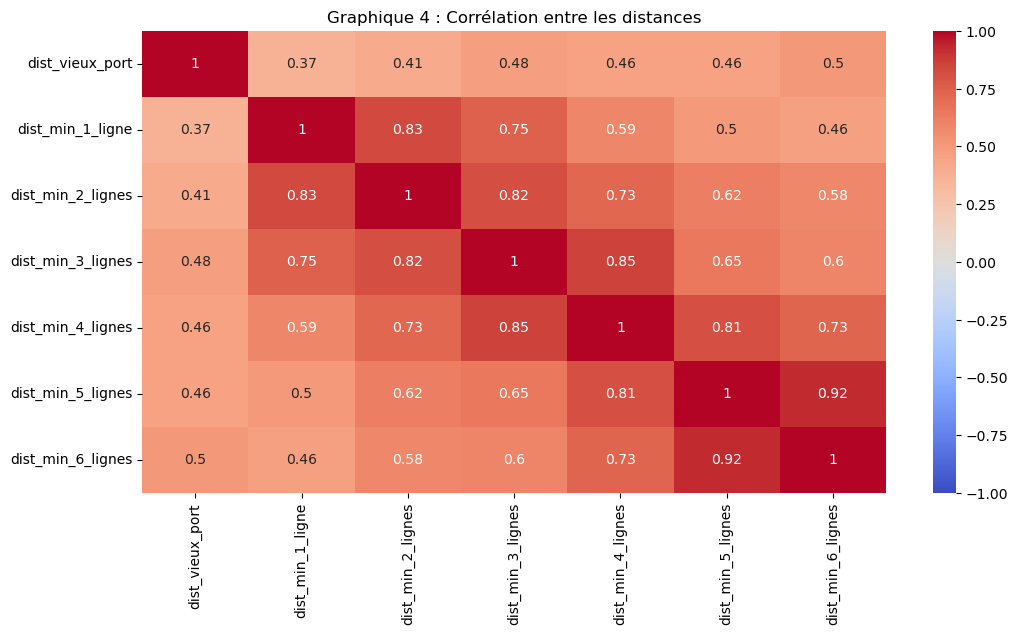

In [23]:
# Corrélations entre les différentes distances 

# Construction de la liste
var_dist_corr = ["dist_vieux_port"]

for i in range(1,7) :
    if i == 1 :
        j = ""
    else :
        j = "s"
    var_dist_corr.append(f"dist_min_{i}_ligne{j}")

# Matrice de corrélation
plt.figure(figsize = (12,6))
sns.heatmap(gdf_carreaux[var_dist_corr].corr(), annot = True, cmap = "coolwarm", vmin = -1, vmax = 1)
plt.title("Graphique 4 : Corrélation entre les distances")

plt.show()

Interprétations : 
---
- Tous les coefficients sont positifs. Plus le nombre de lignes est proche, plus la corrélation entre les deux distances est forte. Cela va dans le sens d'une cohérence des données
- Les corrélations avec la distance au Vieux Port sont positives et ont tendance à augmenter avec le nombre de lignes. Mais elles restent modérées ce qui est également cohérent : les zones d'arrêts ne sont pas toutes proches du Vieux Port mais les plus grosses en général se situent plus près.
- On peut se demander dans quelle mesure ces corrélations répondent à celles vues dans la partie précédente. En ce qui concerne le lien entre réseau et population, on l'a déjà vu précédemment mais quid des questions socio-économiques ?  

### 4.3 Niveau de vie et réseau de transport

In [24]:
# Déciles selon le niveau de vie moyen de sorte à ce que chaque décile représente 10% de la population

# Tri des lignes selon le niveau de vie moyen
gdf_sorted = gdf_carreaux.sort_values("ndv_moy_tous")

# Population cumulée et totale
gdf_sorted["pop_cum"] = gdf_sorted["ind"].cumsum()
total = gdf_sorted["ind"].sum()

# Pourcentage de la population cumulée
gdf_sorted["pop_pct"] = gdf_sorted["pop_cum"] / total

# Découpage en décile
gdf_sorted["decile"] = (gdf_sorted["pop_pct"] * 10).apply(np.floor).astype(int)
gdf_sorted["decile"] = gdf_sorted["decile"].clip(0, 9)

# Vérification 
gdf_sorted.groupby("decile")["ind"].sum()/gdf_sorted["ind"].sum()

decile
0    0.099329
1    0.099975
2    0.100628
3    0.099230
4    0.100083
5    0.099942
6    0.100633
7    0.100076
8    0.100028
9    0.100076
Name: ind, dtype: float64

Le décile noté 0 correspond aux 10% d'habitants les plus pauvres. Le 9 aux 10% les plus riches.

In [25]:
# On vérifie avec une carte que les déciles correspondent aux cartes de Niveau de vie vu plus haut

m = folium.Map(vieux_port, zoom_start=12, tiles="cartodbpositron")

colors = [
    "#313695",
    "#4575b4",
    "#74add1",
    "#abd9e9",
    "#e0f3f8",
    "#ffffbf",
    "#fee090",
    "#fdae61",
    "#f46d43",
    "#d73027"
]

for i,j in zip(range(0,10), colors) :

    folium.GeoJson(gdf_sorted[gdf_sorted["decile"] == i],
                   name = f"D{i}",
                   popup = folium.GeoJsonPopup(fields=["ndv_moy_tous", "ind"]),
                  style_function=lambda x, color=j: {
                    'fillColor': color,
                    'color': "black",
                    'weight': 0.2,
                    'fillOpacity': 0.7
    }).add_to(m) 

save_and_embed(m, "verification_deciles")

Le fait qu'on retrouve plus de carreaux rouges que de carreaux bleus provient de la construction des déciles. Ce n'est pas le nombre de carreaux qui a été découpé en 10 mais bien le nombre d'habitants.

In [26]:
# Observations des moyennes de chaque décile

# Exclusion préalable des colonnes non numériques
col_drop = ["idcar_200m","geometry", "nom_lignes_inside", "nom_lignes_100m", "nom_lignes_200m", "lcog_geo"]
gdf_copy = gdf_sorted.copy()
gdf_col_drop = gdf_copy.drop(columns = col_drop)

# Variables d'intérêt
var = ["zones_inside", "zones_100m", "zones_200m", "nombre_lignes_inside", "nombre_lignes_100m", "nombre_lignes_200m", 
       "dist_min_1_ligne", "dist_min_6_lignes", "dist_vieux_port"]

df = gdf_col_drop.groupby("decile").mean().round(2)[var]
df = df.map(lambda x: f"{x:.2f}")

df

,zones_inside,zones_100m,zones_200m,nombre_lignes_inside,nombre_lignes_100m,nombre_lignes_200m,dist_min_1_ligne,dist_min_6_lignes,dist_vieux_port
decile,,,,,,,,,
0,0.68,2.30,4.27,1.89,4.56,6.41,34.63,770.92,4285.29
1,0.72,2.13,4.21,1.91,3.79,5.46,25.93,811.84,4764.95
2,0.73,1.96,4.09,2.14,3.74,5.49,90.71,890.63,4837.93
3,0.69,2.01,3.96,1.79,3.50,5.10,56.52,753.44,4929.79
4,0.59,1.93,3.82,1.49,3.24,4.89,78.78,828.74,5217.68
5,0.55,1.77,3.45,1.40,3.01,4.27,70.06,850.29,5671.71
6,0.44,1.66,3.36,1.28,2.79,4.23,105.45,882.75,6125.08
7,0.42,1.32,2.85,0.96,2.16,3.28,148.70,1149.17,6402.92
8,0.34,1.24,2.54,0.67,1.73,2.56,181.43,1498.35,6915.74


Observations : 
---
- On observe une tendance à la baisse pour le nombre de zones et de lignes dans un périmètres donnés au fur et à mesure que le décile augmente.
- Les distances par rapport à un nombre donné de lignes ont tendance à augmenter. On peut voir concernant le décile 2 (les 20 à 30% les plus pauvres) une valeur anormalement élevée pour la distance à 1 ligne. Celle-ci est due au fait que dans ce décile se trouve 3 carreaux situés sur l'île du Frioul, ce qui tire la moyenne vers le haut.
- La distance au Vieux Port a elle aussi tendance à augmenter.

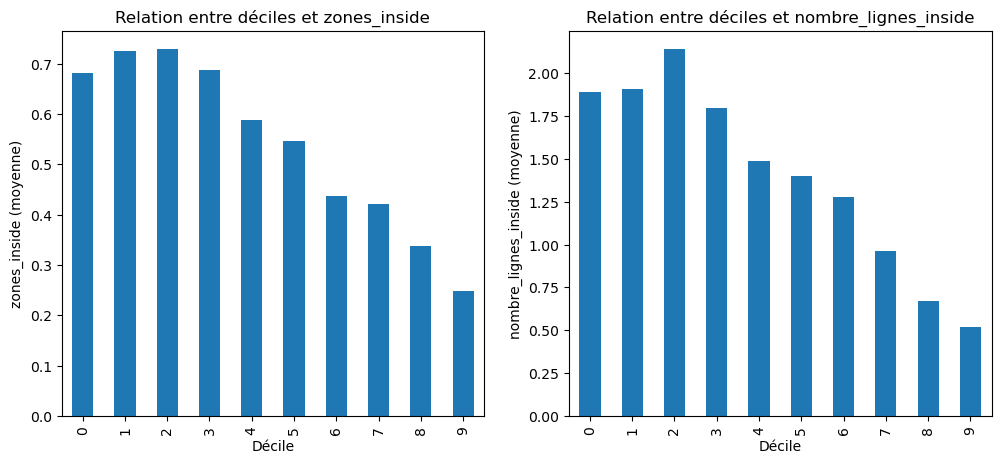

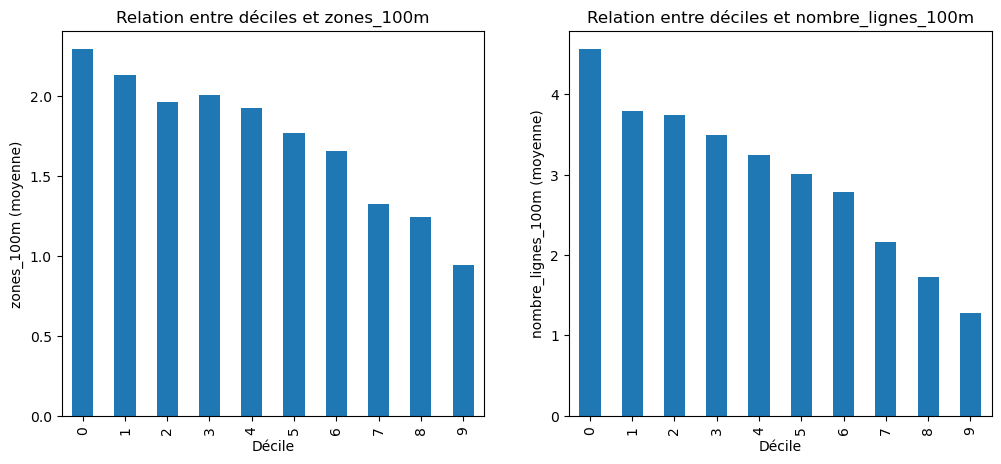

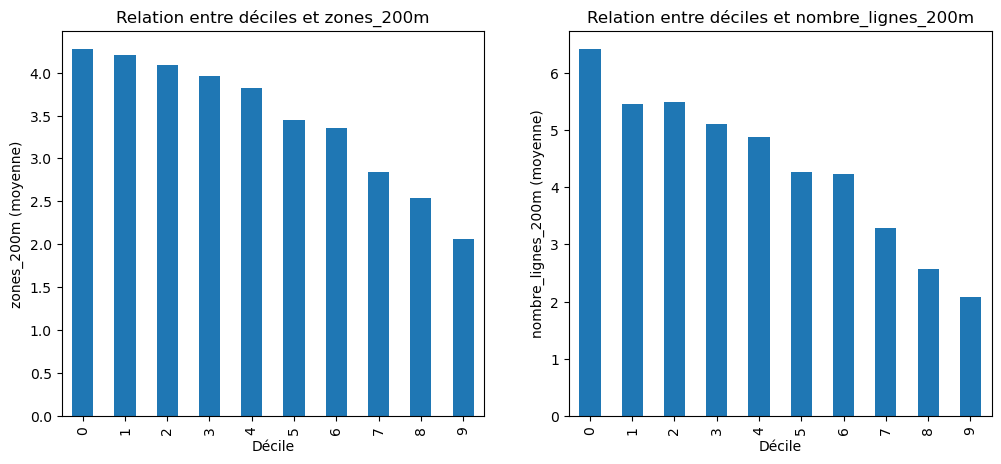

In [27]:
# Visualisation du nombre moyen de zones et de lignes par décile

var_zones = ("zones_inside", "zones_100m", "zones_200m")
var_lignes = ("nombre_lignes_inside", "nombre_lignes_100m", "nombre_lignes_200m")
data = gdf_col_drop.groupby("decile").mean()

# Chaque paire zones, lignes d'un même périmètre produit un diagramme en bar pour chaque élément de la pair
for var_i, var_j in zip(var_zones, var_lignes) :
    plt.figure(figsize = (12,5))
    plt.subplot(1,2,1)
    ax = data[f"{var_i}"].plot(
    kind="bar"
    )
    
    ax.set_xlabel("Décile")
    ax.set_ylabel(f"{var_i} (moyenne)")
    ax.set_title(f"Relation entre déciles et {var_i}")


    plt.subplot(1,2,2)
    ax = data[f"{var_j}"].plot(
    kind="bar"
    )
    
    ax.set_xlabel("Décile")
    ax.set_ylabel(f"{var_j} (moyenne)")
    ax.set_title(f"Relation entre déciles et {var_j}")
    plt.show()

In [28]:
# Test de Spearman pour la monotonie de la relation entre les déciles et les différentes variables présentées graphiquement ci-dessus

corr_zones = []
corr_lignes = []

for i,j in zip(var_zones, var_lignes) :
    rho_zones, p_zones = stats.spearmanr(gdf_sorted["decile"], gdf_sorted[i])
    rho_lignes, p_lignes = stats.spearmanr(gdf_sorted["decile"], gdf_sorted[j])
    
    corr_zones.append(f"{rho_zones :.2f} \n ({p_zones:.4f})")
    corr_lignes.append(f"{rho_lignes :.2f} \n ({p_lignes:.4f})")

df = pd.DataFrame({"zones": corr_zones,
                    "lignes": corr_lignes
                })

df.index = ["inside", "100m", "200m"]

pretty_print(df)

,zones,lignes
inside,-0.26 (0.0000),-0.27 (0.0000)
100m,-0.33 (0.0000),-0.37 (0.0000)
200m,-0.34 (0.0000),-0.40 (0.0000)


On voit dans tous les cas la confirmation de ce que le tableau complet et les graphiques nous indiquaient : une relation décroissante. Elle est toujours statistiquement significative. Les coefficients augmentent avec la taille du périmètre. La question qui se pose est de savoir si cet effet global masque des différences entre les arrondissements.

## 5. Analyse par arrondissement

Un problème se pose concernant les carreaux appartenant à plusieurs arrondissements. 

In [29]:
# Quelle est la proportion de carreaux appartenant à plusieurs arrondissements (ou à un arrondissement et une commune adjacente) ?
gdf_arr_unique = gdf_sorted[gdf_sorted["lcog_geo"].isin(code_geo_marseille)]
(len(gdf_sorted) - len(gdf_arr_unique))/len(gdf_sorted)

0.16990440949737898

Ces carreaux représentent 17% de l'ensemble. Pour simplifier, ces carreaux seront laissées hors de l'analyse par arrondissement. On crée une carte ci-dessous pour visualiser les carreaux restants.

In [30]:
# Carte de base
m = folium.Map(location=vieux_port, zoom_start=12, tiles="cartodbpositron")

colors = [
    "#313695", "#4575b4", "#74add1", "#abd9e9", "#e0f3f8",
    "#ffffbf", "#fee090", "#fdae61", "#f46d43", "#d73027"
]


gdf_sorted = gdf_sorted.copy()

# Association des déciles et des couleurs
gdf_sorted["decile"] = gdf_sorted["decile"].astype(int)
gdf_sorted["color"] = gdf_sorted["decile"].map(lambda d: colors[d])

# Création des couches par arrondissement
for arr in code_geo_marseille:
    num_arr = int(arr) - 13200
    subset = gdf_sorted[gdf_sorted["lcog_geo"] == arr]
    
    layer = folium.FeatureGroup(name=f"Arrondissement {num_arr}")

    folium.GeoJson(
        subset,
        style_function= lambda feature : {
        "fillColor": feature["properties"]["color"],
        "color": "black",
        "weight": 0.2,
        "fillOpacity": 0.7
    },
        tooltip=folium.GeoJsonTooltip(
            fields=["decile", "ndv_moy_tous"],
            aliases=["Décile", "Niveau de vie"]
        )
    ).add_to(layer)

    layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

save_and_embed(m, "deciles_par_arrondissement")

### 5.1 Spearman par arrondissement

In [31]:
var = ["zones_inside", "zones_100m", "zones_200m",
    "nombre_lignes_inside", "nombre_lignes_100m", "nombre_lignes_200m"]

results = []

# Pour chaque variable pour laquelle on a testé le coefficient de Spearman ci-dessus
for v in var:
    
    # Pour chaque arrondissement
    for arr, d in gdf_arr_unique.groupby("lcog_geo"):

        # On fait un test de Spearman
        rho, p = stats.spearmanr(d["ndv_moy_tous"], d[v])

        # Etoiles de significativité
        if p < 0.01:
            star = "***"
        elif p < 0.05:
            star = "**"
        elif p < 0.1:
            star = "*"
        else:
            star = ""
            
        arr = int(arr) - 13200
        
        results.append({
            "arrondissement": arr,
            "variable": v,
            "rho": rho,
            "p_value": p,
            "star": star
        })

res_df = pd.DataFrame(results)

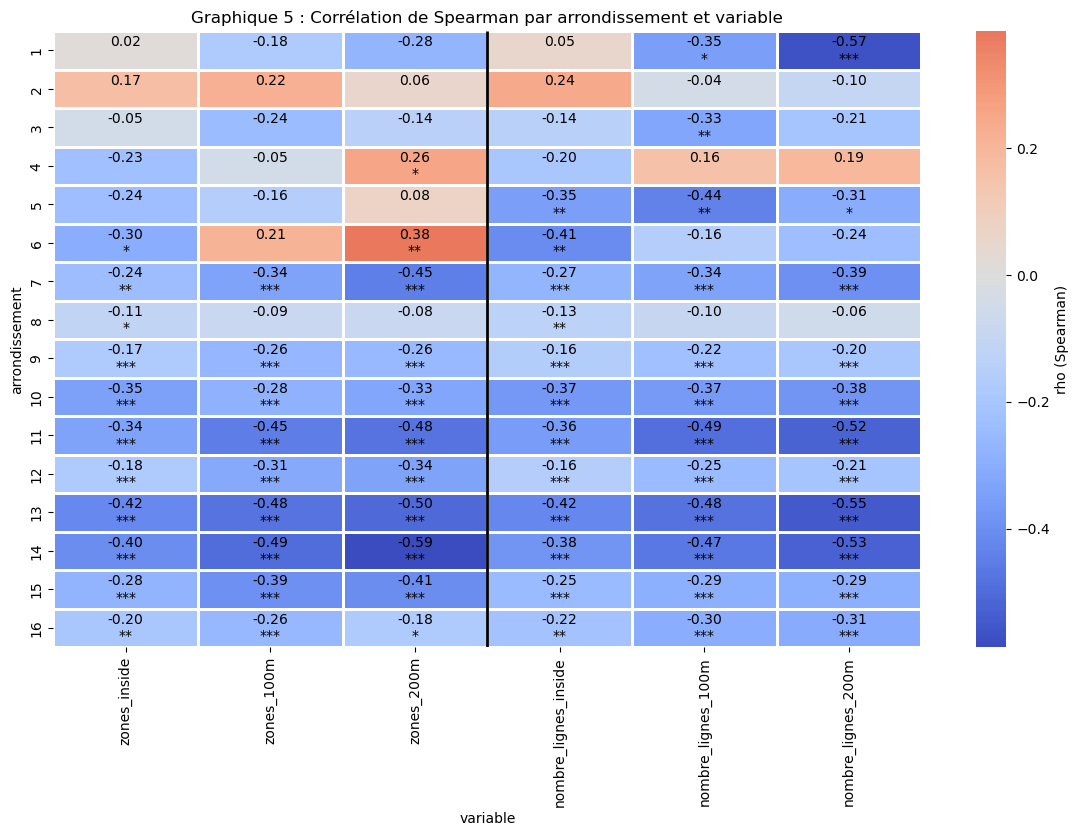

In [32]:
# Pivot de res_df en deux df : un avec les valeurs de rho et l'autre avec les étoiles de significativité
heat = res_df.pivot(index="arrondissement", columns="variable", values="rho")
star_df = res_df.pivot(index="arrondissement", columns="variable", values="star")

# On retrie les variables
heat = heat[var]
star_df = star_df[var]

# Création de la matrice de corrélation en heatmap
plt.figure(figsize=(14,8))

ax = sns.heatmap(
    heat,
    cmap="coolwarm",
    center=0,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "rho (Spearman)"}
)

# Ligne de séparation entre les variables 
ax.vlines(3, *ax.get_ylim(), colors="black", linewidth=2)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        
        rho = heat.iloc[i, j]
        star = star_df.iloc[i, j]
        
        text = f"{rho:.2f}\n{star}"
        
        ax.text(
            j + 0.5,
            i + 0.5,   
            text,
            ha="center",
            va="center",
            fontsize=10
        )

plt.title("Graphique 5 : Corrélation de Spearman par arrondissement et variable")
plt.show()

Interprétations : 
---
- On voit une grande différence entre les arrondissements du centre-ville à l'exception du 7ème, et ceux plus extérieurs, à l'exception du 8ème. Dans le 1er groupe les coefficients sont en majorité non significatifs, indiquant des relations non-monotones. Dans le second, les relations sont en général très significatives statistiquement et négatives. 

### 5.2 Comparaisons graphiques 

On va comparer les graphiques concernant les relations entre niveau de vie moyen et nombre de zones dans les 200m pour les carreaux constituant les 2ème, 7ème, 8ème et 14 arrondissements en guise d'illustration des différences et des similitudes que mettent en avant les coefficients ci-dessus.

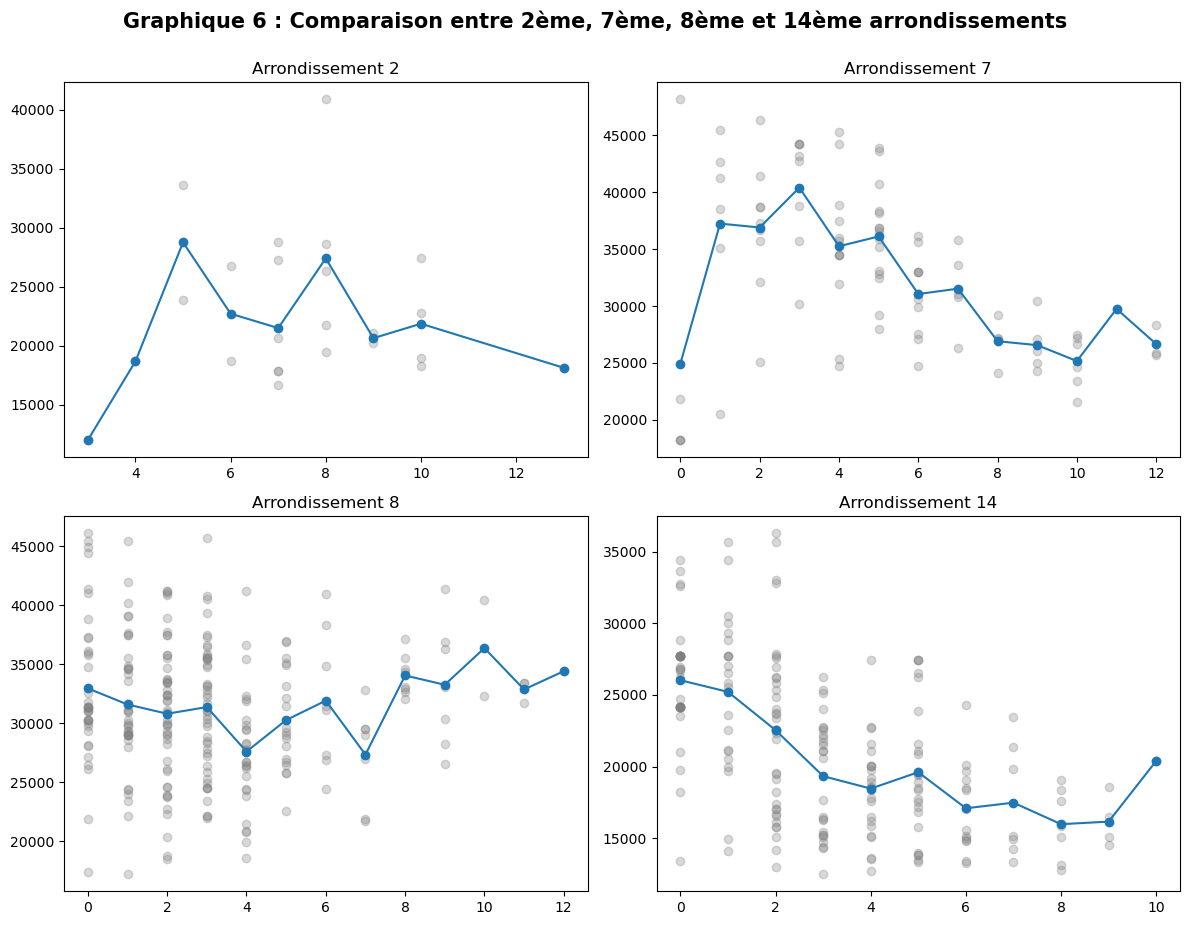

In [33]:
arrondissement = ["13202", "13207", "13208", "13214"]

fig, ((ax_2, ax_7), (ax_8, ax_14)) = plt.subplots(2, 2, figsize=(12, 10))
ycol = "ndv_moy_tous"
xcol = "zones_200m"

for arr, ax in zip(arrondissement, (ax_2, ax_7, ax_8, ax_14)):

    num_arr = int(arr) - 13200
    df = gdf_arr_unique[gdf_arr_unique["lcog_geo"] == arr]

    df = df.dropna(subset=[xcol, ycol])
    df_agg = df.groupby(xcol)[ycol].mean().reset_index().sort_values(xcol)


    ax.scatter(df[xcol], df[ycol], color="gray", alpha=0.3)
    ax.plot(df_agg[xcol], df_agg[ycol], marker="o")
    ax.set_title(f"Arrondissement {num_arr}")

fig.suptitle("Graphique 6 : Comparaison entre 2ème, 7ème, 8ème et 14ème arrondissements", fontsize=15, fontweight="bold", y=0.92)
plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.show()

Interprétations : 
---
- On voit clairement dans les 7ème et 14ème arrondissements les tendances à la baisse du niveau de vie moyen en même temps que le nombre de zones d'arrêts augmente. La hausse, au début pour le 7ème et à la fin pour le 14ème, ne suffit pas à invalider la tendance globale, d'autant qu'elle ne s'appuit que sur un faible nombre d'observations.
- Pour le 2ème arrondissement, on constate un faible nombre d'observations. De plus, la relation ne semble pas monotone mais change de direction.
- Pour le 8ème arrondissement, on semble distingue plutôt une relation en U, même si le nombre d'observations sur les hautes quantités de zones est relativement limité. 

---
## 6. Conclusion
---

### 6.1 La ville de Marseille

- La population est principalement concentrée dans le centre-ville autour du Vieux-Port.
- Les zones les plus peuplées ont tendance à être celles avec les ménages les plus pauvres. A l'inverse, les zones les moins denses ont en général des niveaux de vie moyens plus élevés.
- Mais on observe également une distinction Nord/Sud dans la répartition du niveau de vie dans la ville. Le Nord est associé à une population plus pauvre quand le Sud est habité par des personnes plus aisées.

### 6.2 Le réseau de transport

- Le réseau de transport dessert bien la population avec la quasi-intégralité de la population habitant à 500m ou moins d'un arrêt. 80% des habitants vivent à 500m ou moins d'une zone d'arrêts par laquelle passent au moins 4 lignes. On passe à 50% pour au moins 6 lignes.
- La proximité au Vieux-Port est positivement corrélée à la proximité au réseau, cette corrélation devenant de plus en plus forte à mesure que le nombre de lignes augmente.
- Mais ces corrélations sont modérées. Ceci peut s'expliquer par l'étalement du réseau dans la ville d'une part, ce qui diminue la centralité du Vieux-Port dans la construction du maillage des transports en commun, et d'autre part par l'existence d'autres déterminants. 

### 6.3 Niveau de vie et accès au réseau

- L'accessibilité au réseau et le niveau de vie sont négativement corrélés à l'échelle de la ville. Ainsi, les espaces où les individus sont en moyenne les plus aisées sont plus éloignées du réseau.
- En revanche, au niveau local, des arrondissements, on observe des différences. Concernant les arrondissements périphériques (à l'exception du 8ème), on retrouve la même relation négative entre niveau de vie et accès au réseau. Pour les arrondissements du centre-ville (à l'exception du 7ème), cette relation disparait et devient ambiguë. 

### 6.4 Limite de l'étude

- L'association des lignes à certains arrêts se base sur la seule proximité géographique et non pas sur un arrêt réel. Ceci peut entrainer une erreur de surévaluation dans la mesure de l'accessibilité.
- La construction des zones d'arrêts se base sur le nom des arrêts et non pas sur la proximité spatiale ce qui affecte la mesure des distances à parcourir pour atteindre un certain nombre de lignes.
- L'accessibilité est mésurée selon la présence d'infrastructures et le nombre de lignes y passant, mais pas selon d'autres facteurs essentiels comme la fréquence de passage, l'affluence ou le temps d'attente.
- Les distances présentées ici sont des distances à vol d'oiseau qui ne correspondent donc pas aux distances réellement parcourues par les usagers pour se rendre à une zone d'arrêts.
- Les données utilisées ne permettent pas de donner un aperçu des dynamiques entre l'évolution du réseau de transports et les caractéristiques socio-démographiques de Marseille. Ceci empêche de conclure à toute causalité dans l'analyse.
- L'analyse au niveau local souffre du faible nombre d'observations disponibles pour certains arrondissements. 

### 6.5 Recommandations

- Renforcer la mise à disposition de données ouvertes sur le réseau de transport (association des arrêts et des lignes, horaires théoriques, évolution historique du réseau), afin de favoriser l'évaluation des politiques publiques et le contrôle citoyen.
- Compléter l'analyse par des données temporelles afin d'étudier plus finement les relations entre évolution du réseau et dynamiques démographiques.
- Évaluer les éventuels déséquilibres territoriaux de l'offre de transport à des échelles plus fines, certains arrondissements présentant des relations différentes entre niveau de vie et accessibilité au réseau.